In [77]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from game import BBTAN
from aimbot import get_aimbot_move

# Aimbot - basemodel

In [ ]:
# env setup
aimbot = BBTAN(render_mode=False)
done = False
# Predef var
MAX_LEVEL = 600
COLS = 7
MAX_ROWS = 10
# Data holder
records = []

In [ ]:
while not done and aimbot.level <= MAX_LEVEL:
    # Basic stats
    curr_state = aimbot.get_params()[0]
    
    best_angle = get_aimbot_move(aimbot)
    curr_state['Target_Angle'] = best_angle
    
    # training params 
    curr_state['Start_X'] = aimbot.start_x
    
    for r in range(MAX_ROWS):
        for c in range(COLS):
            curr_state[f'R{r}_C{c}'] = 0
            
    for b in aimbot.blocks:
        if 0 <= b.row < MAX_ROWS and 0 <= b.col < COLS:
            curr_state[f'R{b.row}_C{b.col}'] = b.hp
            
    records.append(curr_state)
    
    if records[-1]['Level'] % 10 == 0:
        print(f"Level {records[-1]['Level']} | Blocks: {records[-1]['Blocks']} | HP: {records[-1]['Blocks_HP']} | Floor: {records[-1]['Floor']}")

    _, _, done, _ = aimbot.step(best_angle)

Level 10 | Blocks: 2 | HP: 18 | Floor: 10
Level 20 | Blocks: 7 | HP: 80 | Floor: 9
Level 30 | Blocks: 3 | HP: 87 | Floor: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 76 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Level         29 non-null     int64  
 1   Floor         29 non-null     int64  
 2   Blocks        29 non-null     int64  
 3   Blocks_HP     29 non-null     int64  
 4   Target_Angle  29 non-null     float64
 5   Start_X       29 non-null     float64
 6   R0_C0         29 non-null     int64  
 7   R0_C1         29 non-null     int64  
 8   R0_C2         29 non-null     int64  
 9   R0_C3         29 non-null     int64  
 10  R0_C4         29 non-null     int64  
 11  R0_C5         29 non-null     int64  
 12  R0_C6         29 non-null     int64  
 13  R1_C0         29 non-null     int64  
 14  R1_C1         29 non-null     int64  
 15  R1_C2         29 non-null     int64 

In [ ]:
df = pd.DataFrame(records)
df.info()
df
os.makedirs("models", exist_ok=True)
df.to_csv("models/bbtan_training_data.csv", index=False)

In [ ]:
aimbot_df = pd.DataFrame(records, columns=['Level', 'Floor', 'Blocks', 'Blocks_HP'])
aimbot_df.info()
aimbot_df
aimbot_df.describe()
os.makedirs("data", exist_ok=True)
aimbot_df.to_csv("data/aimbot_data.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Level      599 non-null    int64
 1   Floor      599 non-null    int64
 2   Blocks     599 non-null    int64
 3   Blocks_HP  599 non-null    int64
dtypes: int64(4)
memory usage: 18.8 KB


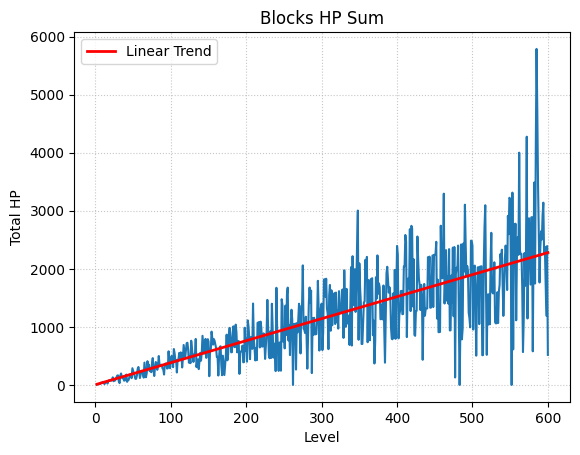

In [79]:
plt.plot(aimbot_df['Level'], aimbot_df['Blocks_HP'])
a = np.polyfit(aimbot_df['Level'], aimbot_df['Blocks_HP'], 1)
aimbot_poly_Blocks_HP = np.poly1d(a)
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks_HP(aimbot_df['Level']), color='red', linewidth=2, label='Linear Trend')
plt.title("Blocks HP Sum")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

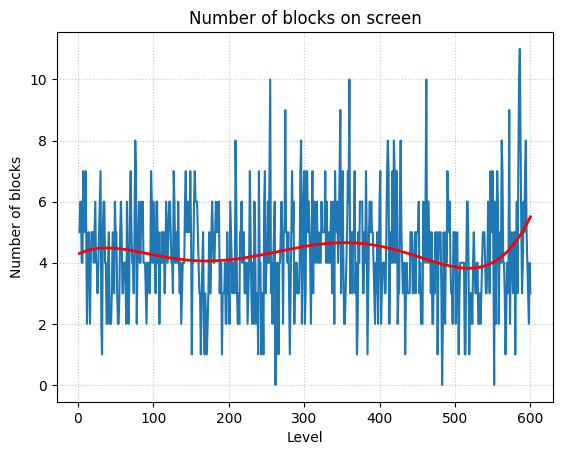

In [81]:
plt.plot(aimbot_df['Level'], aimbot_df['Blocks'])
a = np.polyfit(aimbot_df['Level'], aimbot_df['Blocks'], 5)
aimbot_poly_Blocks = np.poly1d(a)
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks(aimbot_df['Level']), color='red', linewidth=2, label='Quadratic Trend')
plt.title("Number of blocks on screen")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.grid(True, linestyle=':', alpha=0.7)

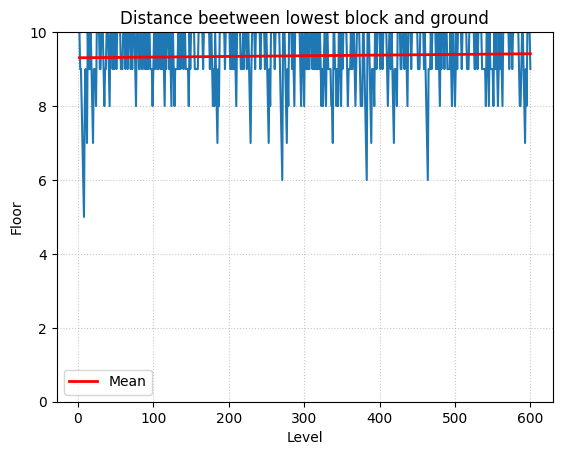

In [82]:
plt.plot(aimbot_df['Level'], aimbot_df['Floor'])
a = np.polyfit(aimbot_df['Level'], aimbot_df['Floor'], 1)
aimbot_poly_Floor = np.poly1d(a)
plt.plot(aimbot_df['Level'], aimbot_poly_Floor(aimbot_df['Level']), color='red', linewidth=2, label='Mean')
plt.title("Distance beetween lowest block and ground")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)

# Rainforced Agent

In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CheckpointCallback
from agent import BBTANGymEnv, get_rainforce_agent_move

### Training set

In [ ]:
%load_ext tensorboard
%tensorboard --logdir=./ppo_bbtan_tensorboard/

In [ ]:
train_env = BBTANGymEnv(render_mode=False)
model_path = "models/bbtan_checkpoint_v2_66200_steps" # Ścieżka do starego modelu (bez .zip)
    
print(f"Wczytywanie starego modelu z {model_path}.zip...")
model = PPO.load(model_path, env=train_env, tensorboard_log="./ppo_bbtan_tensorboard/")
    
TIMESTEPS = 20000 # Ile KOLEJNYCH kroków chcemy go douczyć
    
checkpoint_callback = CheckpointCallback(
    save_freq=5000, 
    save_path='./models/',
    name_prefix='bbtan_checkpoint_v2' # Zmieniamy nazwę, żeby odróżnić nowe checkpointy
)
    
print(f"Wznawiam trening na kolejne {TIMESTEPS} kroków...")
    
try:
    # 2. Po prostu wywołujemy learn() jeszcze raz!
    # reset_num_timesteps=False sprawi, że w TensorBoardzie wykresy będą 
    # ładnie kontynuowane, a nie zaczną się od zera.
    model.learn(total_timesteps=TIMESTEPS, callback=checkpoint_callback, reset_num_timesteps=False)
except KeyboardInterrupt:
    print("\nPrzerwano! Zapisuję obecny stan...")
finally:
    # 3. Zapisujemy zaktualizowany model (możesz nadpisać stary, ale bezpieczniej dodać dopisek v2)
    new_model_path = "models/ppo_bbtan_model_v2"
    model.save(new_model_path)
    print(f"Douczony model zapisano w {new_model_path}.zip")
    train_env.close()

### Test set

In [64]:
# env setup
rainforce_agent = BBTAN(render_mode=False)
model = PPO.load("models/bbtan_checkpoint_v2_66200_steps.zip")
translator_env = BBTANGymEnv(render_mode=False)
done = False
# Predef var
MAX_LEVEL = 600
# Data holder
records = []

In [65]:
while not done and rainforce_agent.level <= MAX_LEVEL:
    # Zbieramy statystyki planszy i DODAJEmy do listy
    obecny_stan = rainforce_agent.get_params()[0]
    records.append(obecny_stan)

    if obecny_stan['Level'] % 10 == 0:
        print(f"Level {obecny_stan['Level']} | Blocks: {obecny_stan['Blocks']} | HP: {obecny_stan['Blocks_HP']} | Floor: {obecny_stan['Floor']}")

    # Agent PPO podejmuje decyzję
    best_angle = get_rainforce_agent_move(rainforce_agent, model, translator_env)
    
    # Gra wykonuje ruch
    _, _, done, _ = rainforce_agent.step(best_angle)

Level 10 | Blocks: 8 | HP: 62 | Floor: 9
Level 20 | Blocks: 7 | HP: 130 | Floor: 9
Level 30 | Blocks: 9 | HP: 220 | Floor: 9
Level 40 | Blocks: 7 | HP: 233 | Floor: 6
Level 50 | Blocks: 3 | HP: 111 | Floor: 9
Level 60 | Blocks: 4 | HP: 189 | Floor: 8
Level 70 | Blocks: 3 | HP: 207 | Floor: 10
Level 80 | Blocks: 12 | HP: 807 | Floor: 8
Level 90 | Blocks: 2 | HP: 178 | Floor: 10
Level 100 | Blocks: 4 | HP: 396 | Floor: 10
Level 110 | Blocks: 4 | HP: 436 | Floor: 10
Level 120 | Blocks: 3 | HP: 357 | Floor: 10
Level 130 | Blocks: 6 | HP: 771 | Floor: 9
Level 140 | Blocks: 11 | HP: 1380 | Floor: 8
Level 150 | Blocks: 10 | HP: 1304 | Floor: 8
Level 160 | Blocks: 7 | HP: 1109 | Floor: 9
Level 170 | Blocks: 9 | HP: 1047 | Floor: 9
Level 180 | Blocks: 4 | HP: 693 | Floor: 9
Level 190 | Blocks: 5 | HP: 943 | Floor: 9
Level 200 | Blocks: 11 | HP: 2140 | Floor: 7
Level 210 | Blocks: 6 | HP: 1250 | Floor: 9
Level 220 | Blocks: 21 | HP: 4193 | Floor: 6
Level 230 | Blocks: 17 | HP: 3077 | Floor: 7
Le

In [83]:
rainforce_agent_df = pd.DataFrame(records)
rainforce_agent_df.info()
rainforce_agent_df
rainforce_agent_df.describe()
os.makedirs("data", exist_ok=True)
rainforce_agent_df.to_csv("data/rainforce_agent_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Level      599 non-null    int64
 1   Floor      599 non-null    int64
 2   Blocks     599 non-null    int64
 3   Blocks_HP  599 non-null    int64
dtypes: int64(4)
memory usage: 18.8 KB


In [ ]:
rainforce_agent_df.describe()

,Level,Floor,Blocks,Blocks_HP
count,599.000000,599.000000,599.000000,599.000000
mean,301.000000,8.455760,7.664441,2124.762938
std,173.060683,1.284444,4.179411,1908.515612
min,2.000000,4.000000,0.000000,0.000000
25%,151.500000,8.000000,5.000000,701.500000
50%,301.000000,9.000000,7.000000,1650.000000
75%,450.500000,9.000000,10.000000,2885.000000
max,600.000000,10.000000,25.000000,11209.000000


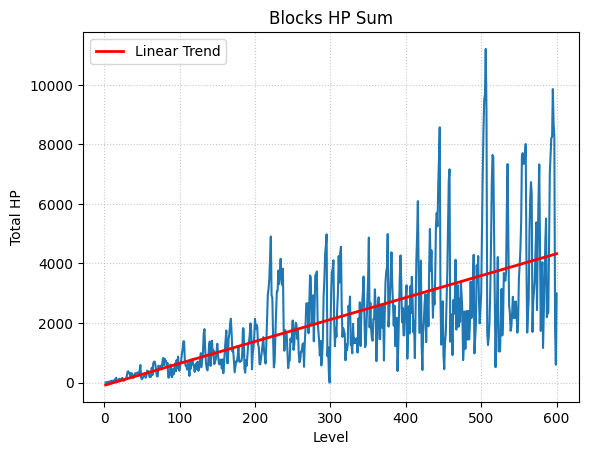

In [69]:
plt.plot(rainforce_agent_df['Level'], rainforce_agent_df['Blocks_HP'])
a = np.polyfit(rainforce_agent_df['Level'], rainforce_agent_df['Blocks_HP'], 1)
rainforce_agent_poly_Blocks_HP = np.poly1d(a)
plt.plot(rainforce_agent_df['Level'], rainforce_agent_poly_Blocks_HP(rainforce_agent_df['Level']), color='red', linewidth=2, label='Linear Trend')
plt.title("Blocks HP Sum")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

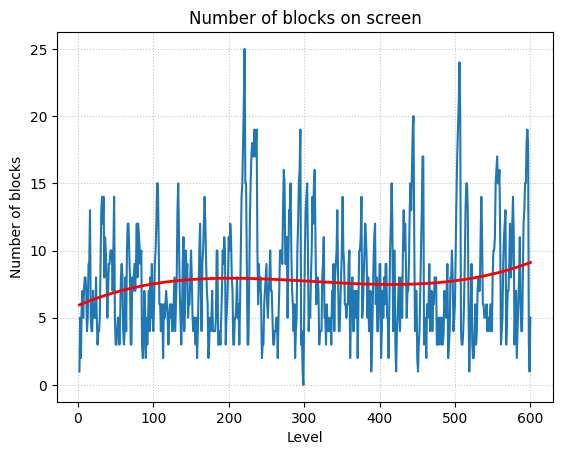

In [70]:
plt.plot(rainforce_agent_df['Level'], rainforce_agent_df['Blocks'])
a = np.polyfit(rainforce_agent_df['Level'], rainforce_agent_df['Blocks'], 3)
rainforce_agent_poly_Blocks = np.poly1d(a)
plt.plot(rainforce_agent_df['Level'], rainforce_agent_poly_Blocks(rainforce_agent_df['Level']), color='red', linewidth=2, label='Quadratic Trend')
plt.title("Number of blocks on screen")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.grid(True, linestyle=':', alpha=0.7)

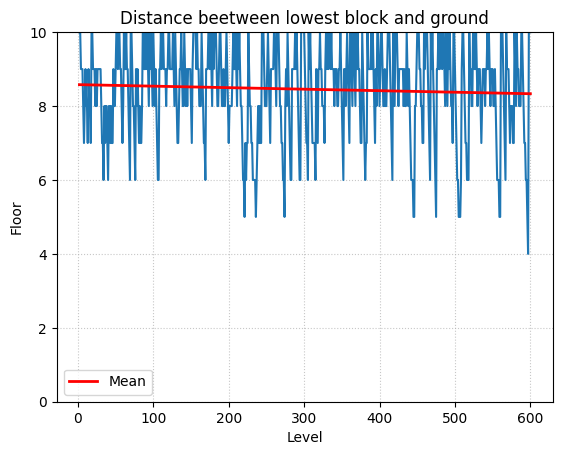

In [71]:
plt.plot(rainforce_agent_df['Level'], rainforce_agent_df['Floor'])
a = np.polyfit(rainforce_agent_df['Level'], rainforce_agent_df['Floor'], 1)
rainforce_agent_poly_Floor = np.poly1d(a)
plt.plot(rainforce_agent_df['Level'], rainforce_agent_poly_Floor(rainforce_agent_df['Level']), color='red', linewidth=2, label='Mean')
plt.title("Distance beetween lowest block and ground")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)

# Supervised agent 

In [111]:
import math
import joblib
from agent import get_supervised_agent_move
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

### Training set prep

In [104]:
df_train = pd.read_csv("data/bbtan_training_data.csv")
del_cols = ['Target_Angle', 'Level', 'Floor', 'Blocks', 'Blocks_HP']
X = df_train.drop(columns=del_cols)
Y = df_train['Target_Angle']
df_train

,Level,Floor,Blocks,Blocks_HP,Target_Angle,Start_X,R0_C0,R0_C1,R0_C2,R0_C3,...,R8_C4,R8_C5,R8_C6,R9_C0,R9_C1,R9_C2,R9_C3,R9_C4,R9_C5,R9_C6
0,2,10,5,5,-0.349066,200.000000,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,3,9,5,8,-0.436332,355.565655,0,2,2,0,...,0,0,0,0,0,0,0,0,0,0
2,4,9,3,7,-0.261799,187.361825,0,0,3,0,...,0,0,0,0,0,0,0,0,0,0
3,5,10,0,0,-0.261799,133.502209,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,6,10,3,15,-0.523599,254.906681,5,5,0,0,...,0,0,0,0,0,0,0,0,0,0
5,7,9,2,11,-0.261799,213.846097,0,0,0,6,...,0,0,0,0,0,0,0,0,0,0
6,8,10,6,42,-2.443461,295.777748,7,7,7,7,...,0,0,0,0,0,0,0,0,0,0
7,9,10,5,40,-2.792527,300.161066,8,8,8,0,...,0,0,0,0,0,0,0,0,0,0
8,10,10,2,18,-0.872665,6.000000,0,0,0,9,...,0,0,0,0,0,0,0,0,0,0
9,11,10,5,50,-0.261799,353.105309,0,10,10,10,...,0,0,0,0,0,0,0,0,0,0


In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [106]:
sl_model = RandomForestRegressor(n_estimators=100, random_state=42)
sl_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
predictions = sl_model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

In [108]:
model_path = "models/supervised_bbtan_model.pkl"
joblib.dump(sl_model, model_path)
print(f"Zapisano model SL w: {model_path}")

Zapisano model SL w: models/supervised_bbtan_model.pkl


In [109]:
sl_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
sl_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### test

In [120]:
sl_model = joblib.load("models/supervised_bbtan_model.pkl")

In [121]:
sl_agent_game = BBTAN(render_mode=False)
done = False
records_sl = []
MAX_LEVEL = 600

In [ ]:
while not done and sl_agent_game.level <= MAX_LEVEL:

    obecny_stan = sl_agent_game.get_params()[0]
    records_sl.append(obecny_stan)

    if obecny_stan['Level'] % 10 == 0:
        print(f"Level {obecny_stan['Level']} | Blocks: {obecny_stan['Blocks']} | HP: {obecny_stan['Blocks_HP']}")

    best_angle = get_supervised_agent_move(sl_agent_game, sl_model)
    _, _, done, _ = sl_agent_game.step(best_angle)

# Tabela i podgląd
df_sl = pd.DataFrame(records_sl)
display(df_sl.head())

Level 10 | Blocks: 4 | HP: 34


,Level,Floor,Blocks,Blocks_HP
0,2,10,3,3
1,3,10,3,6
2,4,9,6,16
3,5,8,9,29
4,6,8,11,45


# Comparision

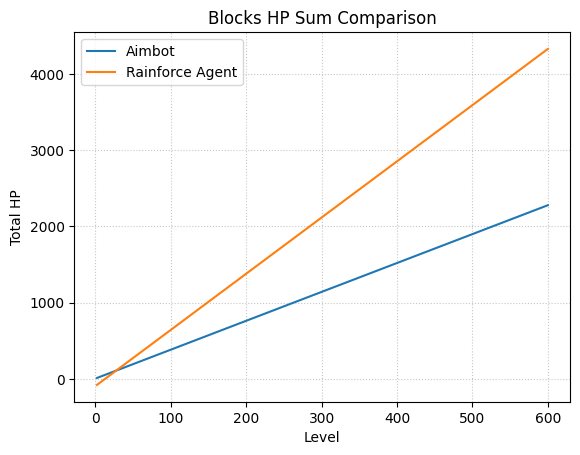

In [84]:
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks_HP(aimbot_df['Level']), label='Aimbot')
plt.plot(rainforce_agent_df['Level'], rainforce_agent_poly_Blocks_HP(rainforce_agent_df['Level']), label='Rainforce Agent')
plt.title("Blocks HP Sum Comparison")
plt.ylabel("Total HP")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

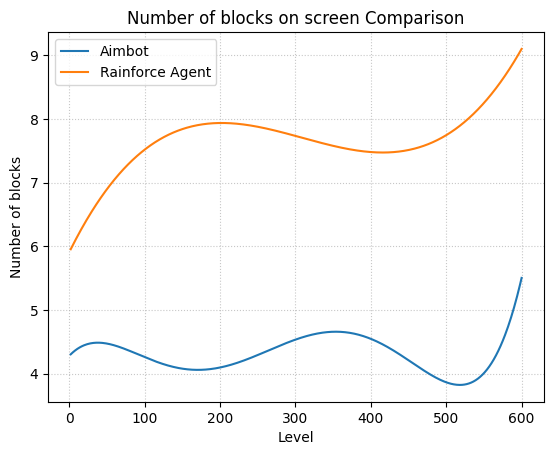

In [85]:
plt.plot(aimbot_df['Level'], aimbot_poly_Blocks(aimbot_df['Level']), label='Aimbot')
plt.plot(rainforce_agent_df['Level'], rainforce_agent_poly_Blocks(rainforce_agent_df['Level']), label='Rainforce Agent')
plt.title("Number of blocks on screen Comparison")
plt.ylabel("Number of blocks")
plt.xlabel("Level")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

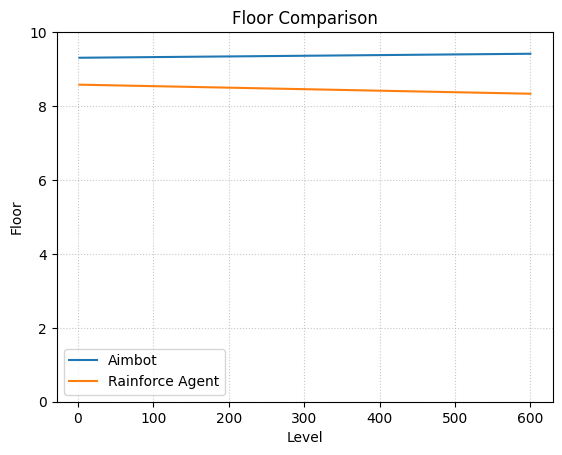

In [86]:
plt.plot(aimbot_df['Level'], aimbot_poly_Floor(aimbot_df['Level']), label='Aimbot')
plt.plot(rainforce_agent_df['Level'], rainforce_agent_poly_Floor(rainforce_agent_df['Level']), label='Rainforce Agent')
plt.title("Floor Comparison")
plt.ylabel("Floor")
plt.xlabel("Level")
plt.legend()
plt.ylim(0, 10)
plt.grid(True, linestyle=':', alpha=0.7)